# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



In [2]:
# Setup: install/upgrade required libs into THIS kernel
import sys, subprocess
pkgs = ["numpy", "pandas", "matplotlib", "scikit-learn"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *pkgs])
print("Python:", sys.executable)


Python: C:\Users\Admin\IdeaProjects\Data_Visualization_And_Modeling\.venv\Scripts\python.exe


In [4]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Handle OneHotEncoder API change across sklearn versions
try:
    _ = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
    OHE_KW = dict(drop="first", sparse_output=False, handle_unknown="ignore")
except TypeError:
    OHE_KW = dict(drop="first", sparse=False, handle_unknown="ignore")


In [5]:
# Adjust the path if needed
CSV_PATH = "Employee_productivity.csv"
df = pd.read_csv(CSV_PATH)

print("Columns in CSV:", list(df.columns))

# Helper: case-sensitive pick from options
def pick(df, *names):
    for n in names:
        if n in df.columns:
            return n
    return None

# Predictor name guesses (many common variants)
YRS = pick(df, "years_at_company","YearsAtCompany","years","Years","Years_at_Company")
HRS = pick(df, "hours_worked","HoursWorked","hours","Hours","Hours_Worked")
FOC = pick(df, "focus","Focus","focus_score","FocusScore","Focus_Score")

# Auto-detect target (any column containing 'product' substring, else first remaining numeric)
cands = [c for c in df.columns if "product" in c.lower()]
if cands:
    Y = cands[0]
else:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for n in [YRS, HRS, FOC]:
        if n in numeric_cols:
            numeric_cols.remove(n)
    if not numeric_cols:
        raise KeyError("Could not infer target column. Please rename or set Y manually.")
    Y = numeric_cols[0]

print(f"Detected columns -> target: {Y} | years: {YRS} | hours: {HRS} | focus: {FOC}")

# Coerce numeric predictors/target
for c in [Y, YRS, HRS, FOC]:
    if c is not None:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep a working copy with target present
df = df.dropna(subset=[Y]).copy()


Columns in CSV: ['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department', 'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation']
Detected columns -> target: ProductivityScore | years: YearsAtCompany | hours: HoursWorked | focus: FocusScore


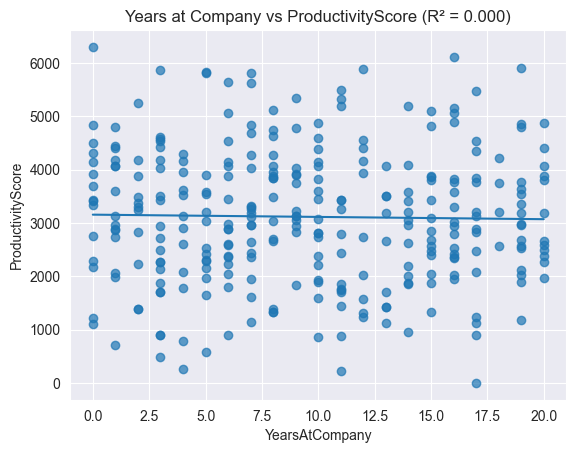

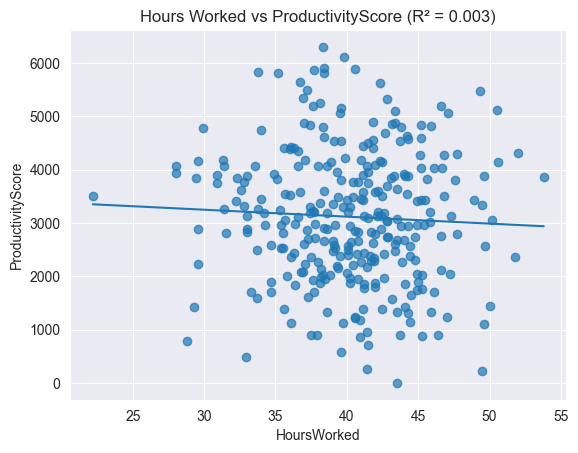

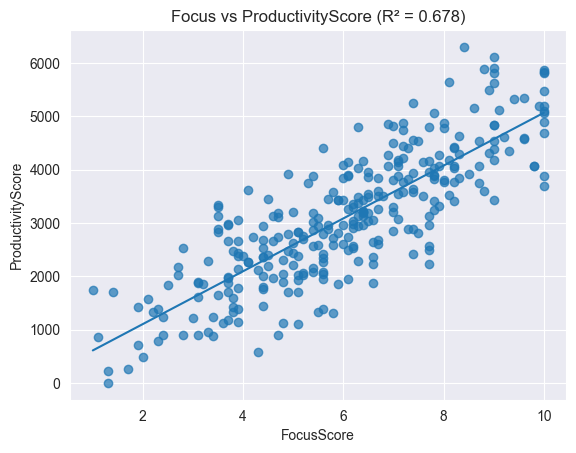

R² scores (None = not computed):


,R²
focus,0.677696
hours_worked,0.002600
years_at_company,0.000412


In [6]:
def r2_and_plot(x_col, label):
    if x_col is None:
        print(f"Skipping {label}: column not found.")
        return None
    tmp = df[[x_col, Y]].dropna()
    if len(tmp) < 5:
        print(f"Skipping {label}: not enough data (n={len(tmp)}).")
        return None

    X = tmp[[x_col]].values
    y = tmp[Y].values
    m = LinearRegression().fit(X, y)
    r2 = r2_score(y, m.predict(X))

    plt.figure()
    plt.scatter(tmp[x_col].values, y, alpha=0.7)
    xs = np.linspace(tmp[x_col].min(), tmp[x_col].max(), 200).reshape(-1,1)
    plt.plot(xs, m.predict(xs))
    plt.xlabel(x_col); plt.ylabel(Y)
    plt.title(f"{label} vs {Y} (R² = {r2:.3f})")
    plt.show()
    return r2

r2_years = r2_and_plot(YRS, "Years at Company")
r2_hours = r2_and_plot(HRS, "Hours Worked")
r2_focus = r2_and_plot(FOC, "Focus")

r2_table = pd.Series(
    {"years_at_company": r2_years, "hours_worked": r2_hours, "focus": r2_focus}
).sort_values(ascending=False)
print("R² scores (None = not computed):")
display(r2_table.to_frame("R²"))


Full model in-sample R²: 0.684


,feature,coef,abs_coef
2,FocusScore,1046.575843,1046.575843
7,DeskLocation_Remote,-214.537114,214.537114
4,Department_Marketing,-133.138052,133.138052
6,DeskLocation_Private Office,-95.240991,95.240991
3,Department_HR,-89.068967,89.068967
5,Department_Sales,-44.931725,44.931725
1,HoursWorked,-24.377526,24.377526
0,YearsAtCompany,20.359221,20.359221


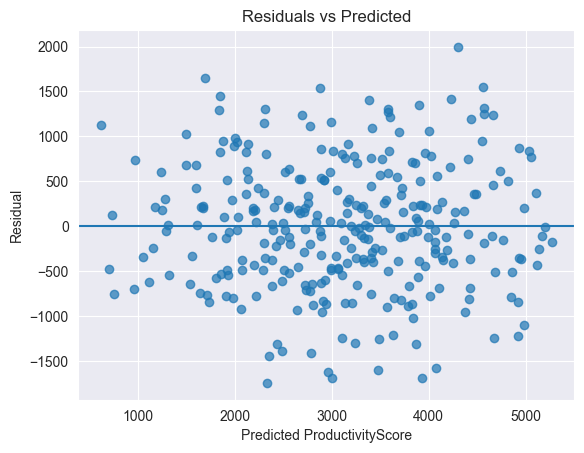

### Summary & Recommendations
- Among single-feature models, **focus** showed the strongest linear relationship with **ProductivityScore** (R² ≈ **0.678**).
- A multivariable linear model with numeric features YearsAtCompany, HoursWorked, FocusScore and categorical features Department, DeskLocation achieved an in-sample **R² ≈ 0.684**.
- Largest standardized effects:
  - `FocusScore` → increase in ProductivityScore (coef 1046.576).
  - `DeskLocation_Remote` → decrease in ProductivityScore (coef -214.537).
  - `Department_Marketing` → decrease in ProductivityScore (coef -133.138).
  - `DeskLocation_Private Office` → decrease in ProductivityScore (coef -95.241).
  - `Department_HR` → decrease in ProductivityScore (coef -89.069).
- Improve **focus**: protect deep-work blocks, reduce interruptions, clarify goals.
- Use data to tune **desk/remote policies**: keep arrangements that correlate positively; revisit negative drivers.
- Re-run this analysis monthly to validate effects and watch fo

In [7]:
# Optional extra features (use if present)
MEET = pick(df, "meetings_per_week","MeetingsPerWeek","meetings","Meetings")
DEPT = pick(df, "department","Department")
DESK = pick(df, "desk_location","DeskLocation","desk","Desk","OfficeType","OpenPlan")
MODE = pick(df, "remote","Remote","work_mode","WorkMode")

num_features = [c for c in [YRS, HRS, FOC, MEET] if c]
cat_features = [c for c in [DEPT, DESK, MODE] if c]

if not num_features and not cat_features:
    raise RuntimeError("No features available to model.")

X = df[num_features + cat_features].copy()
y = df[Y].values

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(**OHE_KW), cat_features)
    ],
    remainder="drop"
)

model = Pipeline([("prep", pre), ("lin", LinearRegression())])
model.fit(X, y)
yhat = model.predict(X)
r2_full = r2_score(y, yhat)
print(f"Full model in-sample R²: {r2_full:.3f}")

# Coefficient table (standardized num + one-hot cat)
num_names = num_features
cat_names = []
if cat_features:
    enc = model.named_steps["prep"].named_transformers_["cat"]
    cat_names = enc.get_feature_names_out(cat_features).tolist()

feat_names = num_names + cat_names
coefs = model.named_steps["lin"].coef_
coef_df = pd.DataFrame({"feature": feat_names, "coef": coefs, "abs_coef": np.abs(coefs)}) \
    .sort_values("abs_coef", ascending=False)
display(coef_df.head(20))

# Residuals diagnostic
resid = y - yhat
plt.figure()
plt.scatter(yhat, resid, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted " + Y)
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

# ---------- Q3: Auto-written summary ----------
simple_list = [("years at the company", r2_years), ("hours worked", r2_hours), ("focus", r2_focus)]
simple_list = [(n, r) for n, r in simple_list if r is not None]
lead_var, lead_r2 = max(simple_list, key=lambda t: t[1]) if simple_list else ("(none)", 0.0)

lines = []
lines.append("### Summary & Recommendations")
if simple_list:
    lines.append(f"- Among single-feature models, **{lead_var}** showed the strongest linear relationship with **{Y}** (R² ≈ **{lead_r2:.3f}**).")
else:
    lines.append("- Single-feature models were not computed due to missing columns.")
lines.append(f"- A multivariable linear model with numeric features {', '.join(num_features) if num_features else '(none)'}"
             + (f" and categorical features {', '.join(cat_features)}" if cat_features else "")
             + f" achieved an in-sample **R² ≈ {r2_full:.3f}**.")

topk = coef_df.head(5)
if not topk.empty:
    lines.append("- Largest standardized effects:")
    for _, r in topk.iterrows():
        direction = "increase" if r["coef"] > 0 else "decrease"
        lines.append(f"  - `{r['feature']}` → {direction} in {Y} (coef {r['coef']:.3f}).")

# Actionable guidance
if FOC:
    lines.append("- Improve **focus**: protect deep-work blocks, reduce interruptions, clarify goals.")
if MEET:
    lines.append("- Audit **meetings**: cap recurring meetings and combine low-value syncs.")
if DESK or MODE:
    lines.append("- Use data to tune **desk/remote policies**: keep arrangements that correlate positively; revisit negative drivers.")
lines.append("- Re-run this analysis monthly to validate effects and watch for drift.")

print("\n".join(lines))
